<a href="https://colab.research.google.com/github/Jumiranda28/Projeto_integrador/blob/main/PII2_gold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Steps:
#Arquitetura Medelhão
#1 - Bronze - Abrir o CSV via python, dar uma olhada, salvar um arquivo .Parquet, o nome CSL no arquivo significa que vai para etapa Silver
#2 - Silver - Abrir .Parquet via python, tratar duplicados, tratar nulls, colocar os DataTypes corretos, salvar um arquivo .Parquet, o nome TGT no arquivo significa que vai para etapa Gold
#3 - Gold

In [5]:
#To connect with Google Drive
from google.colab import drive
drive.mount('/content/drive')
google_drive_prefix = "/content/drive/MyDrive/cdai/csv/"

Mounted at /content/drive


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# arquitetura medalhão:

# t - table
# his - history

# terrasignal - nome da base fornecida

# ing - ingestion
# csl - consolidated
# tgt - target
# ddm - data delivery modal, data mart

name_of_step = "tgt"

terrasignal_parquet_filename = "t_his_terrasignal_" + name_of_step + ".parquet"

df = pd.read_parquet(google_drive_prefix + terrasignal_parquet_filename, engine='pyarrow')

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'CustomerFeedback', 'MonthlyIncome'],
      dtype='object')

In [8]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerFeedback,MonthlyIncome
0,4578-PHJYZ,Male,0,Yes,Yes,52,Yes,No,DSL,No,...,Yes,No,One year,Yes,Electronic check,68.75,3482.85,No,I have been a customer with this internet prov...,6532.0
1,6289-CPNLD,Male,0,Yes,Yes,33,Yes,No,DSL,No,...,Yes,Yes,One year,Yes,Mailed check,73.90,2405.05,Yes,I've been a customer with this company for ove...,7634.0
2,2682-KEVRP,Female,1,No,No,22,Yes,No,No,No internet service,...,No internet service,No internet service,One year,Yes,Mailed check,20.05,417.00,No,I have been a customer with this company for 2...,3628.0
3,5697-GOMBF,Female,1,Yes,Yes,28,No,No phone service,DSL,No,...,Yes,No,Month-to-month,Yes,Electronic check,35.90,973.65,No,I have been a customer with this internet prov...,7851.0
4,9717-QEBGU,Male,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.30,144.00,No,I have been using the fiber optic internet ser...,1691.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,8909-BOLNL,Male,0,No,No,3,Yes,No,No,No internet service,...,No internet service,No internet service,One year,No,Mailed check,21.20,52.05,No,I have been a customer with this company for 3...,8354.0
5630,2832-KJCRD,Female,0,No,No,38,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,103.65,3988.50,No,I have been a customer with this company for 3...,9308.0
5631,7975-JMZNT,Male,0,Yes,No,66,Yes,Yes,DSL,Yes,...,Yes,Yes,Two year,No,Bank transfer (automatic),91.70,6075.90,No,I have been a customer with this DSL internet ...,2113.0
5632,4250-ZBWLV,Male,0,No,No,68,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,No,Electronic check,108.45,7176.55,Yes,I have been a customer with this company for o...,3904.0


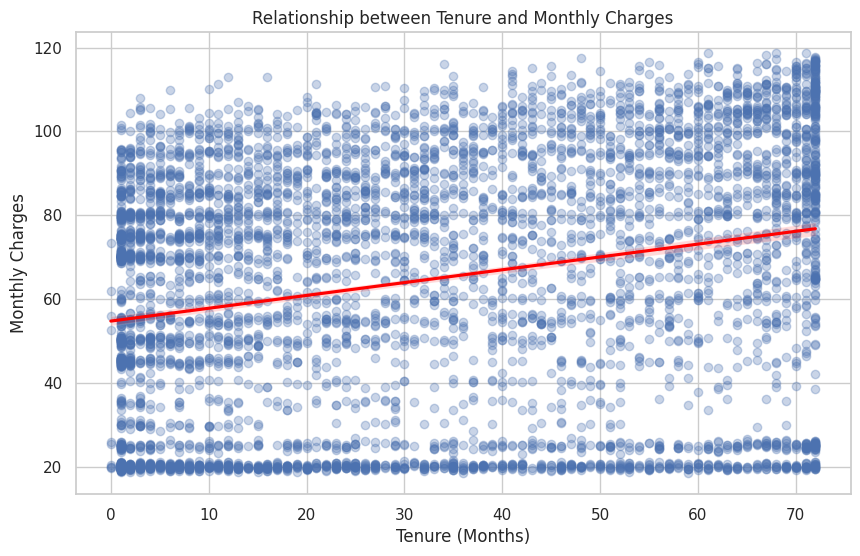

In [20]:
plt.figure(figsize=(10, 6))

plot_df = df.copy()
plot_df['tenure'] = pd.to_numeric(plot_df['tenure'], errors='coerce')
plot_df['MonthlyCharges'] = pd.to_numeric(plot_df['MonthlyCharges'], errors='coerce')

sns.regplot(data=plot_df, x='tenure', y='MonthlyCharges', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship between Tenure and Monthly Charges')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')
plt.show()

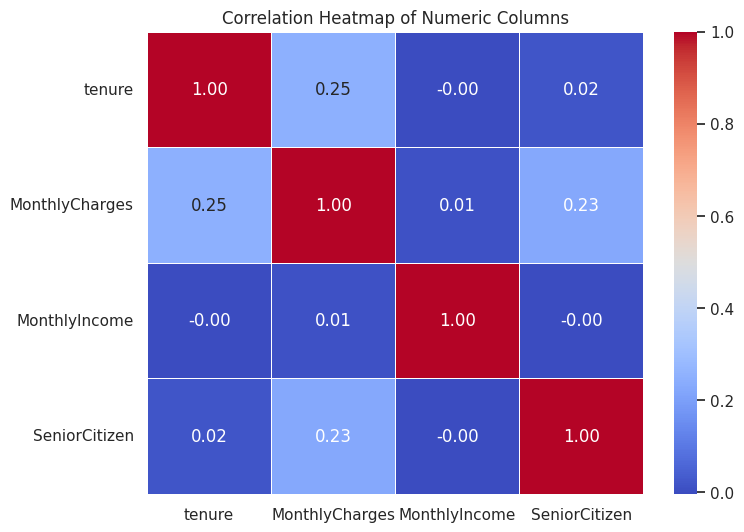

In [21]:
# Ensure proper numeric types before correlation
numeric_df = df.copy()
numeric_cols = ['tenure', 'MonthlyCharges', 'MonthlyIncome', 'SeniorCitizen']

for col in numeric_cols:
    if col in numeric_df.columns:
        numeric_df[col] = pd.to_numeric(numeric_df[col], errors='coerce')

# Calculate correlation matrix
corr_matrix = numeric_df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Columns')
plt.show()

/tmp/ipykernel_2124/2478205969.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='MonthlyIncome', ax=axes[0], palette='Set2')
/tmp/ipykernel_2124/2478205969.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='gender', y='MonthlyIncome', ax=axes[1], palette='Set2', errorbar=None)


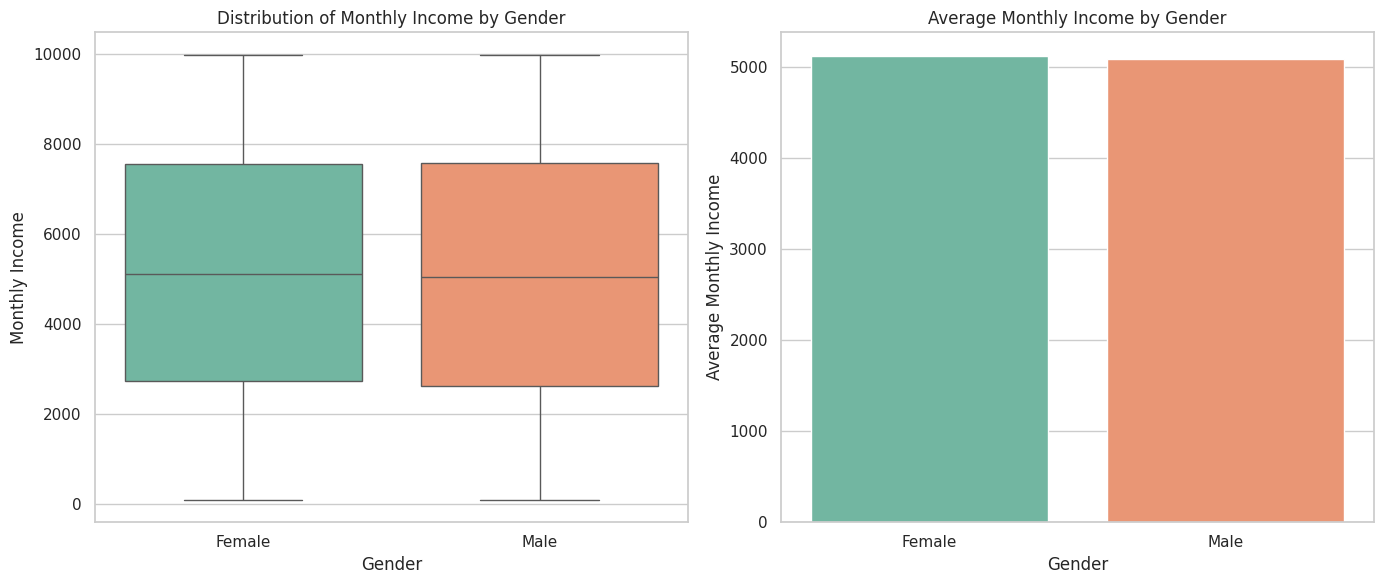

In [10]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='gender', y='MonthlyIncome', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of Monthly Income by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Monthly Income')

sns.barplot(data=df, x='gender', y='MonthlyIncome', ax=axes[1], palette='Set2', errorbar=None)
axes[1].set_title('Average Monthly Income by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Average Monthly Income')

plt.tight_layout()
plt.show()

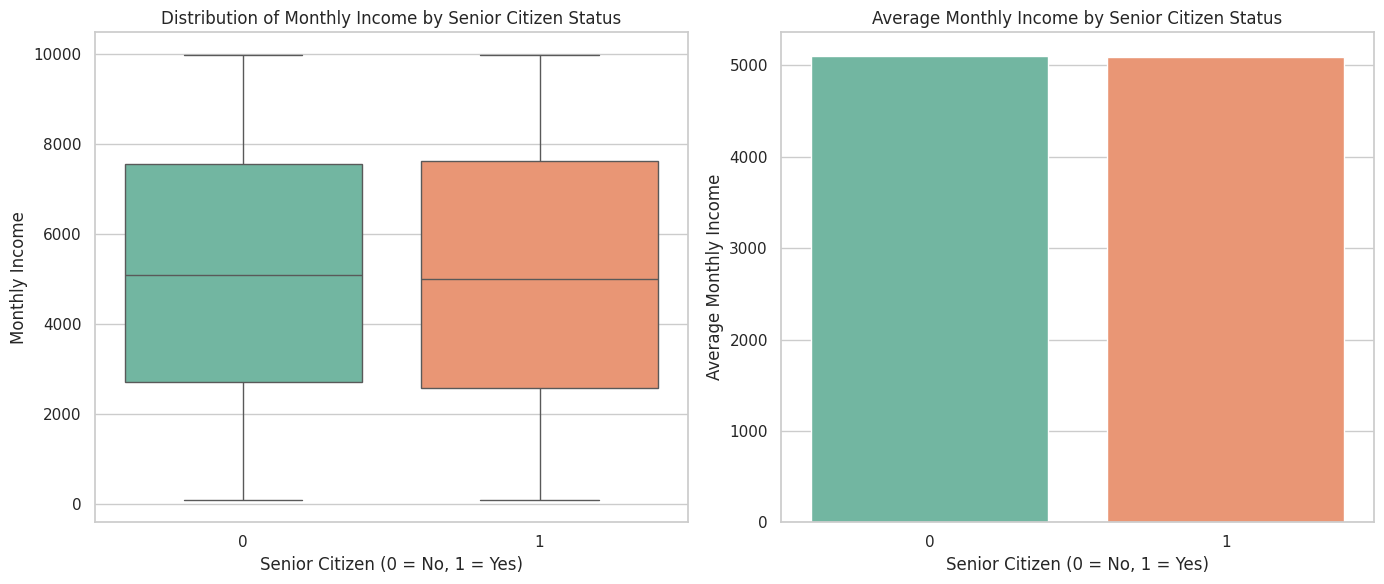

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='SeniorCitizen', y='MonthlyIncome', ax=axes[0], palette='Set2', hue='SeniorCitizen', legend=False)
axes[0].set_title('Distribution of Monthly Income by Senior Citizen Status')
axes[0].set_xlabel('Senior Citizen (0 = No, 1 = Yes)')
axes[0].set_ylabel('Monthly Income')

sns.barplot(data=df, x='SeniorCitizen', y='MonthlyIncome', ax=axes[1], palette='Set2', errorbar=None, hue='SeniorCitizen', legend=False)
axes[1].set_title('Average Monthly Income by Senior Citizen Status')
axes[1].set_xlabel('Senior Citizen (0 = No, 1 = Yes)')
axes[1].set_ylabel('Average Monthly Income')

plt.tight_layout()
plt.show()

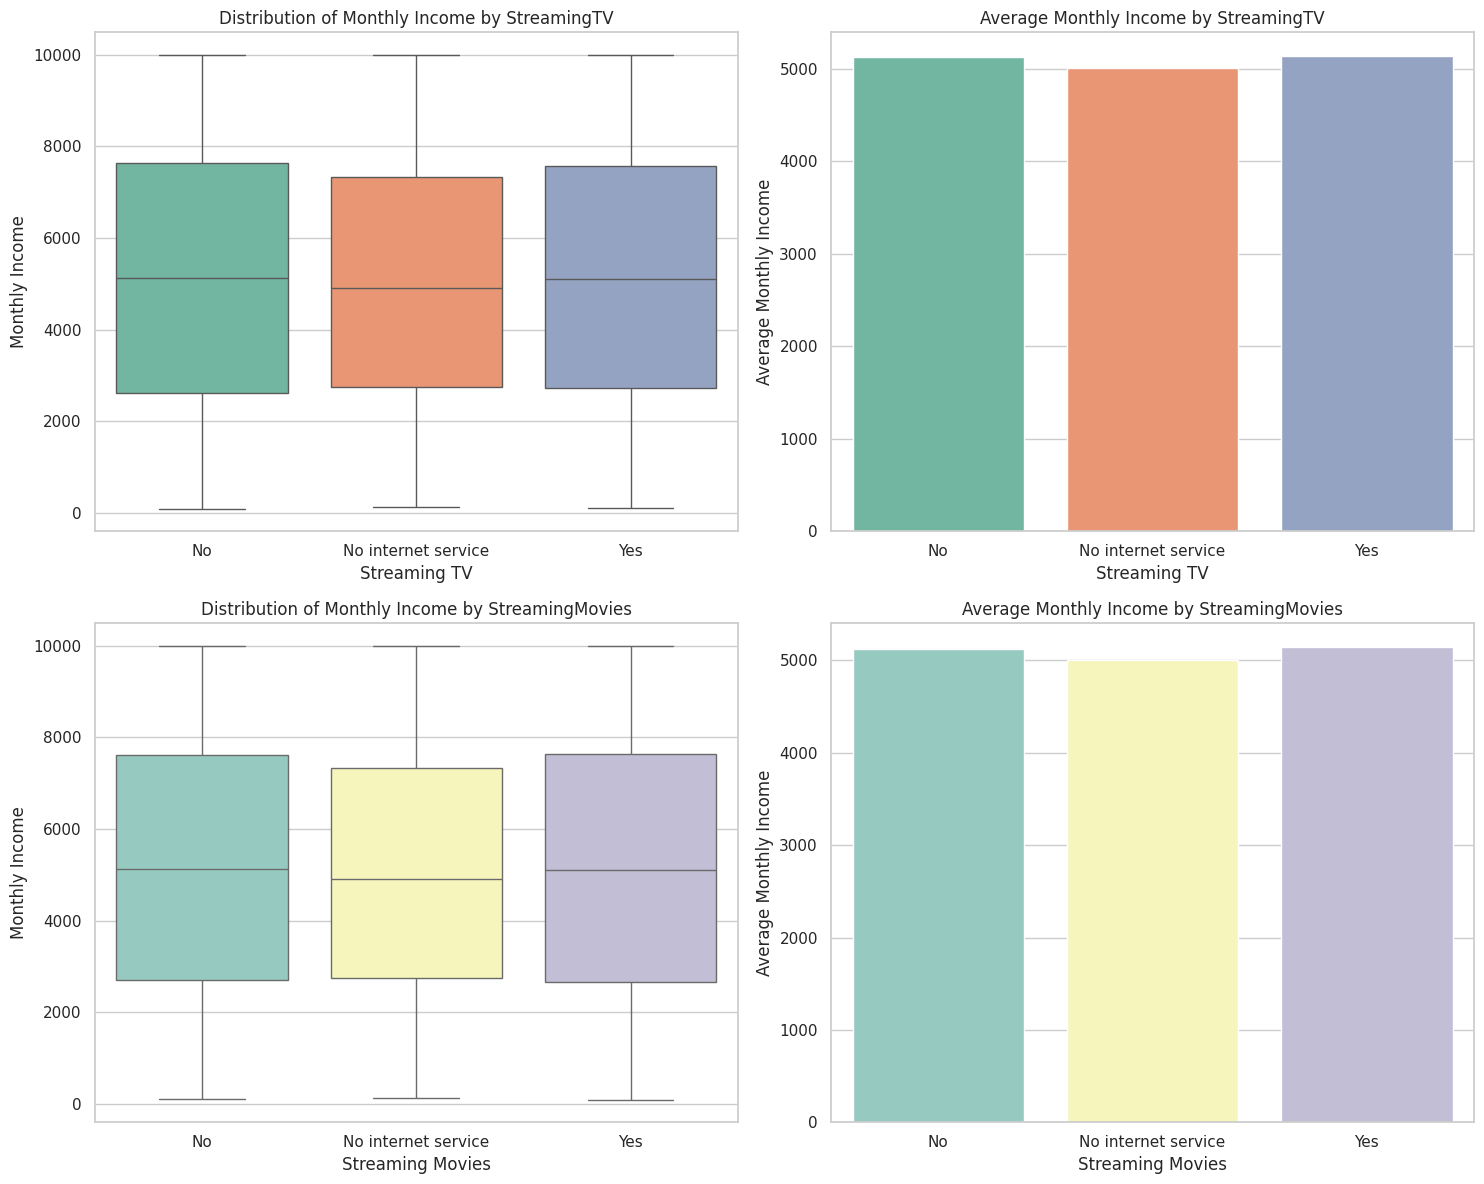

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. StreamingTV vs MonthlyIncome
sns.boxplot(data=df, x='StreamingTV', y='MonthlyIncome', ax=axes[0, 0], palette='Set2', hue='StreamingTV', legend=False)
axes[0, 0].set_title('Distribution of Monthly Income by StreamingTV')
axes[0, 0].set_xlabel('Streaming TV')
axes[0, 0].set_ylabel('Monthly Income')

sns.barplot(data=df, x='StreamingTV', y='MonthlyIncome', ax=axes[0, 1], palette='Set2', errorbar=None, hue='StreamingTV', legend=False)
axes[0, 1].set_title('Average Monthly Income by StreamingTV')
axes[0, 1].set_xlabel('Streaming TV')
axes[0, 1].set_ylabel('Average Monthly Income')

# 2. StreamingMovies vs MonthlyIncome
sns.boxplot(data=df, x='StreamingMovies', y='MonthlyIncome', ax=axes[1, 0], palette='Set3', hue='StreamingMovies', legend=False)
axes[1, 0].set_title('Distribution of Monthly Income by StreamingMovies')
axes[1, 0].set_xlabel('Streaming Movies')
axes[1, 0].set_ylabel('Monthly Income')

sns.barplot(data=df, x='StreamingMovies', y='MonthlyIncome', ax=axes[1, 1], palette='Set3', errorbar=None, hue='StreamingMovies', legend=False)
axes[1, 1].set_title('Average Monthly Income by StreamingMovies')
axes[1, 1].set_xlabel('Streaming Movies')
axes[1, 1].set_ylabel('Average Monthly Income')

plt.tight_layout()
plt.show()

In [22]:

descriptive_stats = df.describe(include='all')
display(descriptive_stats)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerFeedback,MonthlyIncome
count,5634,5634,5634.000000,5634,5634,5634,5634,5634,5634,5634,...,5634,5634,5634,5634,5634,5634.000000,5356.000000,5634,5634,5634.000000
unique,5634,2,NaN,2,2,74,4,3,3,3,...,3,3,3,2,4,NaN,NaN,2,5634,NaN
top,9995-HOTOH,Male,NaN,No,No,1,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No,"Unfortunately, I had to cancel my service afte...",NaN
freq,1,2835,NaN,2907,3949,475,5041,2704,2477,2803,...,2219,2224,3099,3327,1888,NaN,NaN,4130,1,NaN
mean,NaN,NaN,0.164714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,64.609523,2271.883150,NaN,NaN,5104.879304
std,NaN,NaN,0.370955,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,30.152186,2253.784765,NaN,NaN,2839.230500
min,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,18.400000,18.800000,NaN,NaN,100.000000
25%,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,35.162500,412.900000,NaN,NaN,2693.750000
50%,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,70.300000,1390.725000,NaN,NaN,5079.500000
75%,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,89.800000,3729.750000,NaN,NaN,7574.750000


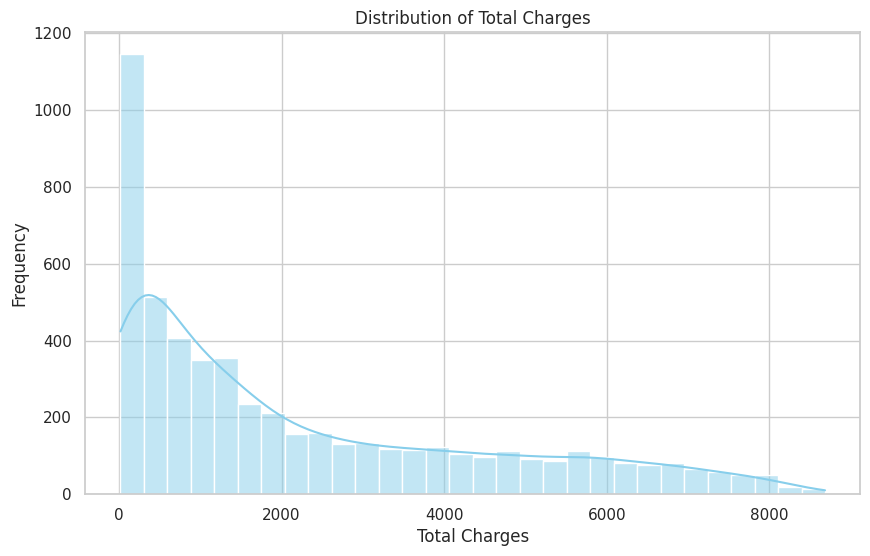

In [23]:
# Ensure 'TotalCharges' is numeric
plot_df = df.copy()
plot_df['TotalCharges'] = pd.to_numeric(plot_df['TotalCharges'], errors='coerce')

# Plot distribution histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x='TotalCharges', kde=True, color='skyblue', bins=30)
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.show()

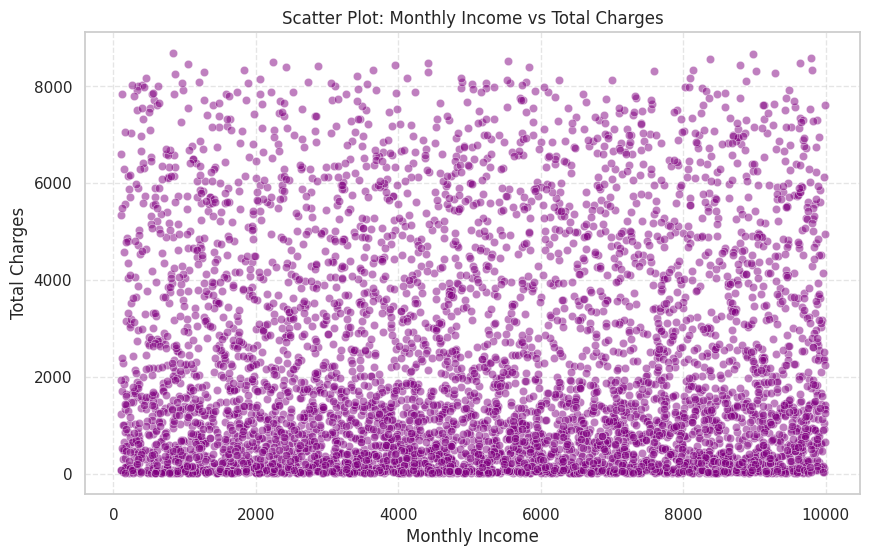

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare numeric columns
scatter_df = df.copy()
scatter_df['MonthlyIncome'] = pd.to_numeric(scatter_df['MonthlyIncome'], errors='coerce')
scatter_df['TotalCharges'] = pd.to_numeric(scatter_df['TotalCharges'], errors='coerce')

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x='MonthlyIncome', y='TotalCharges', alpha=0.5, color='purple')
plt.title('Scatter Plot: Monthly Income vs Total Charges')
plt.xlabel('Monthly Income')
plt.ylabel('Total Charges')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [9]:
name_of_step = "ddm"

terrasignal_parquet_filename = "t_his_terrasignal_" + name_of_step + ".parquet"

df.to_parquet(google_drive_prefix + terrasignal_parquet_filename, engine="pyarrow", compression="snappy")